In [4]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
def load_and_prepare(path, scaler=None, label_encoder=None, fit_scaler=True, fit_encoder=True):
    """
    Load dataset, compute astrophysical features, assign galaxy morphology labels,
    and return scaled feature matrix X and encoded labels y.
    """

    # Load CSV file into dataframe
    df = pd.read_csv(path)

    # Compute g-r color index (difference between g-band and r-band magnitudes)
    # → This measures the galaxy’s color:
    #    small g-r = blue (young stars, star formation),
    #    large g-r = red (old stars, little star formation).
    df["g-r"] = df["g_cmodel_mag"] - df["r_cmodel_mag"]

    # Define morphology classes using astrophysical rules
    # Rule 1: Ellipticals → high Sérsic index (n > 2.5) & red (g-r > 0.65)
    # Rule 2: Irregulars → very low Sérsic index (n < 1.5) & blue (g-r < 0.50)
    # Else: Spirals (default)
    conditions = [
        (df["i_sersic_index"] > 2.5) & (df["g-r"] > 0.65),
        (df["i_sersic_index"] < 1.5) & (df["g-r"] < 0.50)
    ]
    choices = ["elliptical", "irregular"]
    df["label"] = np.select(conditions, choices, default="spiral")

    # Features
    feature_cols = [
        "i_sersic_index",      # Light profile shape
        "i_ellipticity",       # Shape flattening (disky vs round)
        "i_half_light_radius", # Galaxy size
        "g_cmodel_mag",        # Brightness in g-band
        "r_cmodel_mag",        # Brightness in r-band
        "i_cmodel_mag",        # Brightness in i-band
        "z_cmodel_mag",        # Brightness in z-band
        "g-r"                  # Computed color index
    ]
    X = df[feature_cols].values
    y = df["label"].values

    # Encode labels as integers
    if label_encoder is None and fit_encoder:
        label_encoder = LabelEncoder()
        y_encoded = label_encoder.fit_transform(y)
    else:
        y_encoded = label_encoder.transform(y)

    # Scale features - Important because features have different units
    # (magnitudes, radii, indices).
    if scaler is None and fit_scaler:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)  # Fit + scale
    else:
        X_scaled = scaler.transform(X)  # Reuse fitted scaler

    return X_scaled, y_encoded, df, scaler, label_encoder

In [6]:
# === Load datasets ===

# Training set: fit scaler + encoder
X_train, y_train, df_train, scaler, le = load_and_prepare(
    "5x127x127_training_with_morphology.csv", fit_scaler=True, fit_encoder=True
)

# Validation set: reuse scaler + encoder (for consistency)
X_val, y_val, df_val, _, _ = load_and_prepare(
    "5x127x127_validation_with_morphology.csv", scaler=scaler, label_encoder=le,
    fit_scaler=False, fit_encoder=False
)

# Test set: also reuse scaler + encoder
X_test, y_test, df_test, _, _ = load_and_prepare(
    "5x127x127_testing_with_morphology.csv", scaler=scaler, label_encoder=le,
    fit_scaler=False, fit_encoder=False
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 204573
Validation samples: 40914
Testing samples: 40914


In [7]:
# === Train classifiers ===

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)    # Random Forest model

svm = SVC(kernel="linear", C=1.0, random_state=42, class_weight="balanced")
svm.fit(X_train, y_train)   # Linear SVM model

SVC(class_weight='balanced', kernel='linear', random_state=42)


Training - RandomForestClassifier Results
              precision    recall  f1-score   support

  elliptical       1.00      1.00      1.00     44699
   irregular       1.00      1.00      1.00     25883
      spiral       1.00      1.00      1.00    133991

    accuracy                           1.00    204573
   macro avg       1.00      1.00      1.00    204573
weighted avg       1.00      1.00      1.00    204573



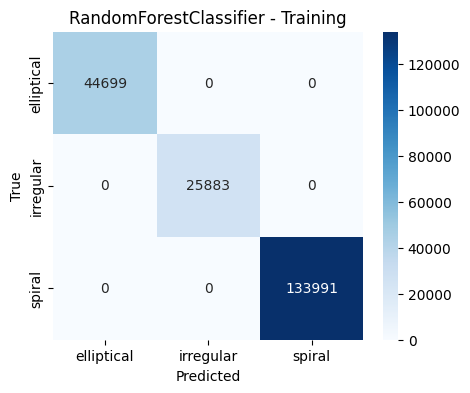


Training - SVC Results
              precision    recall  f1-score   support

  elliptical       0.77      0.97      0.86     44699
   irregular       0.66      0.96      0.78     25883
      spiral       0.98      0.81      0.89    133991

    accuracy                           0.86    204573
   macro avg       0.80      0.91      0.84    204573
weighted avg       0.89      0.86      0.87    204573



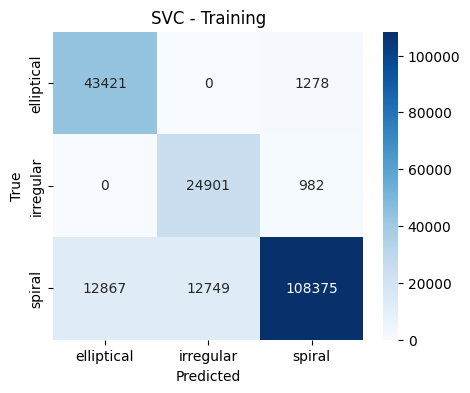


Validation - RandomForestClassifier Results
              precision    recall  f1-score   support

  elliptical       1.00      1.00      1.00      9069
   irregular       1.00      1.00      1.00      5015
      spiral       1.00      1.00      1.00     26830

    accuracy                           1.00     40914
   macro avg       1.00      1.00      1.00     40914
weighted avg       1.00      1.00      1.00     40914



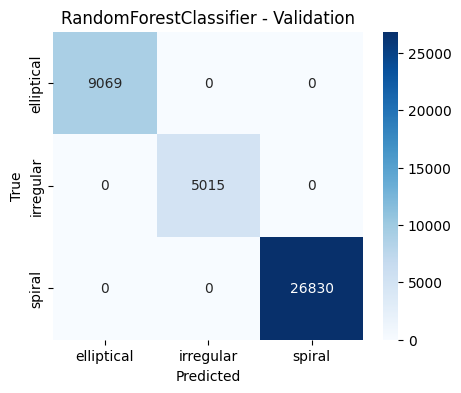


Validation - SVC Results
              precision    recall  f1-score   support

  elliptical       0.77      0.97      0.86      9069
   irregular       0.65      0.96      0.77      5015
      spiral       0.98      0.81      0.88     26830

    accuracy                           0.86     40914
   macro avg       0.80      0.91      0.84     40914
weighted avg       0.89      0.86      0.87     40914



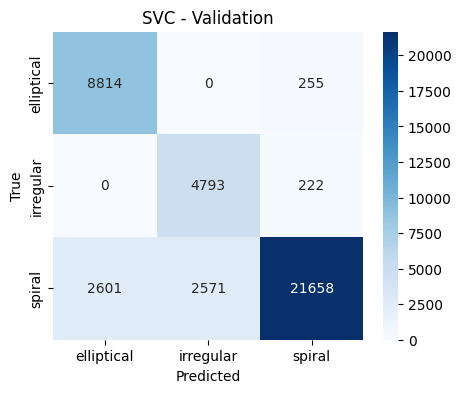


Testing - RandomForestClassifier Results
              precision    recall  f1-score   support

  elliptical       1.00      1.00      1.00      8986
   irregular       1.00      1.00      1.00      5065
      spiral       1.00      1.00      1.00     26863

    accuracy                           1.00     40914
   macro avg       1.00      1.00      1.00     40914
weighted avg       1.00      1.00      1.00     40914



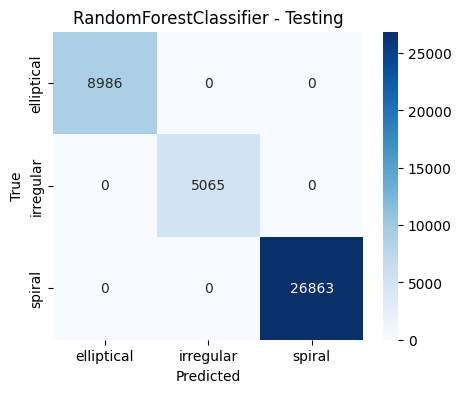


Testing - SVC Results
              precision    recall  f1-score   support

  elliptical       0.77      0.97      0.86      8986
   irregular       0.66      0.96      0.78      5065
      spiral       0.98      0.81      0.89     26863

    accuracy                           0.86     40914
   macro avg       0.80      0.91      0.84     40914
weighted avg       0.89      0.86      0.87     40914



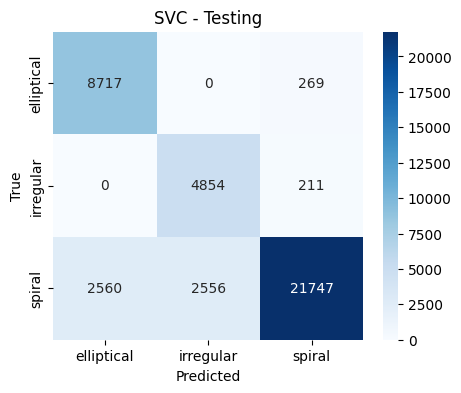

In [8]:
# === Evaluation function ===
def evaluate(model, X, y, dataset_name):
    y_pred = model.predict(X)

    # Print classification metrics (precision, recall, F1-score)
    print(f"\n{dataset_name} - {model.__class__.__name__} Results")
    print(classification_report(y, y_pred, target_names=le.classes_))

    # Confusion matrix plot
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"{model.__class__.__name__} - {dataset_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# === Run evaluation on all datasets for both models ===
for dataset, (X, y) in {
    "Training": (X_train, y_train),
    "Validation": (X_val, y_val),
    "Testing": (X_test, y_test)
}.items():
    evaluate(rf, X, y, dataset)
    evaluate(svm, X, y, dataset)

In [12]:
# === Feature importance analysis ===
feature_cols = [
    "i_sersic_index", "i_ellipticity", "i_half_light_radius",
    "g_cmodel_mag", "r_cmodel_mag", "i_cmodel_mag", "z_cmodel_mag",
    "g-r"
]

# Random Forest importance
print("\nRandom Forest Feature Importances:")
importances = rf.feature_importances_
for feature, imp in sorted(zip(feature_cols, importances), key=lambda x: -x[1]):
    print(f"{feature:20s}: {imp:.3f}")

# SVM feature weights
print("\nSVM Feature Weights (absolute):")
svm_coefs = np.abs(svm.coef_)
mean_coefs = np.mean(svm_coefs, axis=0)
for feature, coef in sorted(zip(feature_cols, mean_coefs), key=lambda x: -x[1]):
    print(f"{feature:20s}: {coef:.3f}")



Random Forest Feature Importances:
i_sersic_index      : 0.494
g-r                 : 0.337
z_cmodel_mag        : 0.044
i_cmodel_mag        : 0.044
i_half_light_radius : 0.038
g_cmodel_mag        : 0.020
r_cmodel_mag        : 0.016
i_ellipticity       : 0.007

SVM Feature Weights (absolute):
i_sersic_index      : 2.734
g-r                 : 2.131
z_cmodel_mag        : 1.188
g_cmodel_mag        : 0.537
i_cmodel_mag        : 0.401
r_cmodel_mag        : 0.330
i_half_light_radius : 0.060
i_ellipticity       : 0.003


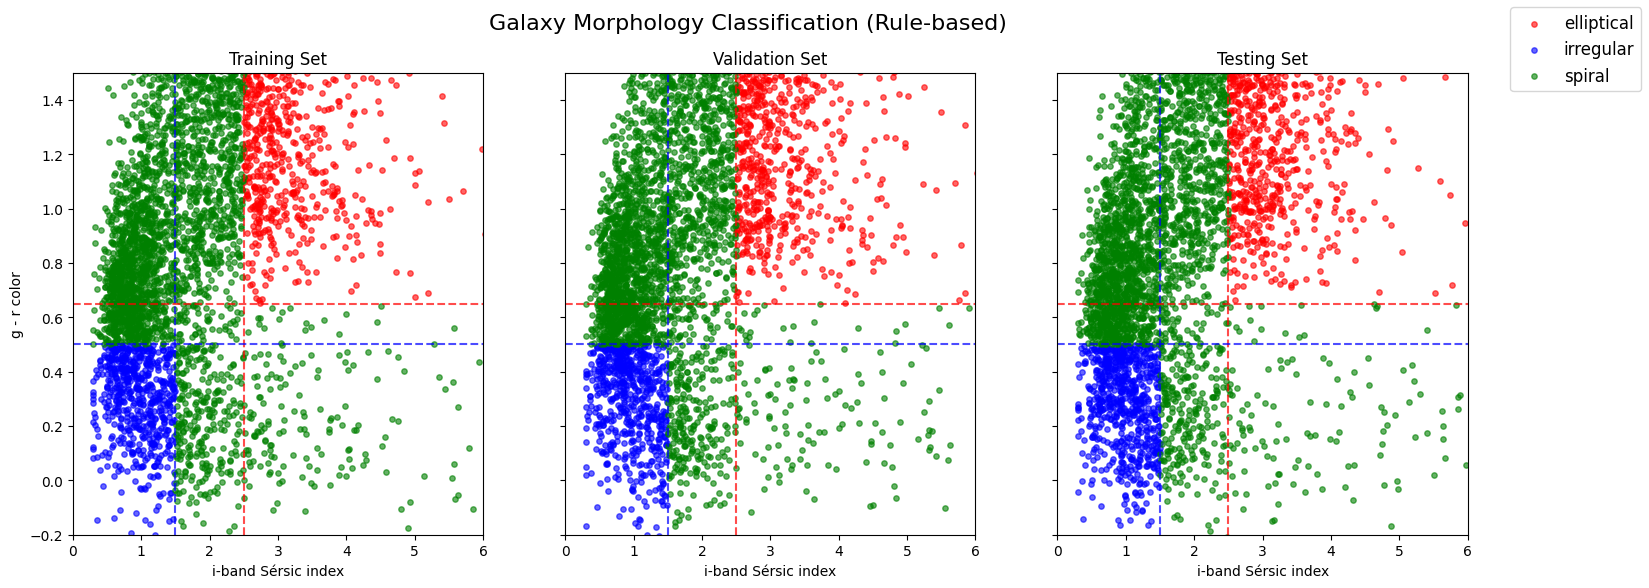

In [10]:
# === Visualization of rule-based separation in (Sérsic index vs g-r) space ===
def plot_morphology_space_multi(datasets, sample_size=5000):
    """
    Scatterplot of Sérsic index vs g-r color for multiple datasets.
    Colors indicate morphology class. Rule-based cut lines are drawn.
    """
    colors = {"elliptical": "red", "spiral": "green", "irregular": "blue"}

    fig, axes = plt.subplots(1, len(datasets), figsize=(18,6), sharey=True)

    for ax, (df, name) in zip(axes, datasets):
        # Subsample for plotting and readability (to avoid overly dense plots)
        if len(df) > sample_size:
            df_plot = df.sample(sample_size, random_state=42)
        else:
            df_plot = df

        # Scatterplot by class
        for label, group in df_plot.groupby("label"):
            ax.scatter(group["i_sersic_index"], group["g-r"],
                       c=colors[label], label=label, alpha=0.6, s=15)

        # Rule boundaries
        ax.axvline(1.5, color="blue", linestyle="--", alpha=0.7)
        ax.axvline(2.5, color="red", linestyle="--", alpha=0.7)
        ax.axhline(0.50, color="blue", linestyle="--", alpha=0.7)
        ax.axhline(0.65, color="red", linestyle="--", alpha=0.7)

        ax.set_xlabel("i-band Sérsic index")
        ax.set_title(name)
        ax.set_xlim(0, 6)   # adjust depending on data
        ax.set_ylim(-0.2, 1.5)  # adjust depending on data

    axes[0].set_ylabel("g - r color")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=12)
    fig.suptitle("Galaxy Morphology Classification (Rule-based)", fontsize=16)
    plt.show()

# Visualize for train, val, and test
plot_morphology_space_multi([
    (df_train, "Training Set"),
    (df_val, "Validation Set"),
    (df_test, "Testing Set")
])